In [1]:
import calibration_wrappers as calwrap
import caldata
import os, os.path
import pyuvdata as uv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def display_all_images():
    path = os.path.abspath(os.getcwd()) + '/images/'
    files = [name for name in os.listdir('./images') if not os.path.isdir(os.path.join(path, name))]
    print(files)
    for file in files:
        img = plt.imread("./images/"+file)
        _ = plt.imshow(img)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

***CAL WRAPPER***
	Ant Pairs [(1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 3), (2, 4), (2, 5), (2, 6), (3, 4), (3, 5), (3, 6), (4, 5), (4, 6), (5, 6)]
Done. Data read time 0.01087658405303955 minutes.
Formatting data...
***SEED*** 1746678215
Done. Data formatting time 0.02463393211364746 minutes.
Running calibration optimization...
***STARTING FUNCTION VALUE*** 169272.82418520798
***JAC - GAINS***
 [  2002.7 -13312.9  12795.5 -11220.5  21153.7  -4024.3  -1522.4  -4451.8
   1807.5  -5161.4  10595.1   4585.2]
***JAC - FIT VIS***
 [  41.1    2.  -398.4   -1.7  440.7    0.7 -181.3   -0.5  883.8   -0.8
 -608.7    0.2   29.4   -1.2 -616.4   -0.5 -333.9    3.3 -179.9   -2.3
  129.1   -0.4   24.9   -5.2 -349.1    1.4 -237.1   -1.2 -308.3    0.6]
***JAC - GAINS***
 [  1936.5 -13243.1  12623.7 -11104.7  20845.9  -3928.4  -1576.1  -4405.5
   1788.2  -5155.   10432.8   4581.5]
***JAC - FIT VIS***
 [  40.3    2.  -395.8   -1.7  440.9    0.7 -181.5   -0.5  884.1   -0.8
 -605.1    0.2   28.4   -1.2 -6

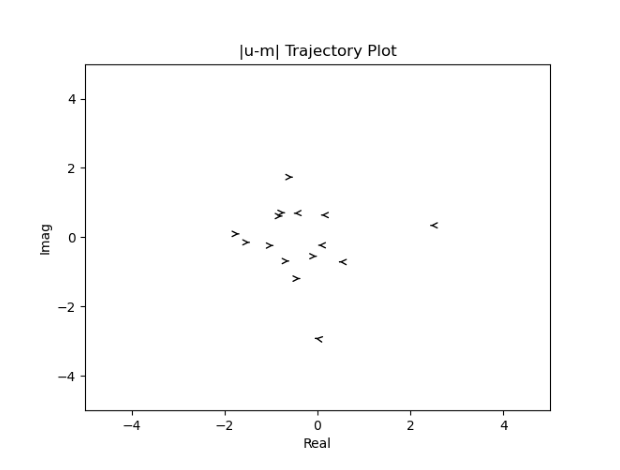

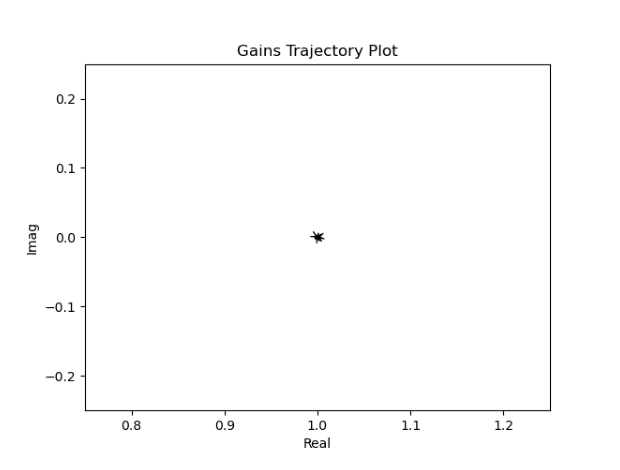

In [ ]:
# uvc = calwrap.sky_based_calibration_wrapper('data/tutorial_full_onetime_unflagged.uvfits',
#                                             'data/tutorial_full_onetime_unflagged.uvfits',
#                                             parallel=False,
#                                             gain_init_stddev=0.1,
#                                             verbose=True,)

uvc = calwrap.unified_calibration_wrapper('data/tutorial_small-mix_degen.uvfits',
                                          'data/tutorial_small-mix_degen.uvfits',
                                          parallel=False,
                                          gain_init_stddev=0.1,
                                          fit_vis_init_stddev=0,
                                          verbose=True,)

# test_powell()
display_all_images()

In [ ]:
test_arr1 = np.asarray([1,2,3,4])
test_arr2 = np.asarray([5,6,7,8])
test_arr3 = np.asarray([9,10,11,12,13])
test_arr4 = np.asarray([14,15,16,17,18])

first_flattened_array = np.stack(
    (
        test_arr1, 
        test_arr2
    ), 
    axis=1,
).flatten()
print(first_flattened_array)

second_flattened_array = np.stack(
    (
        test_arr3,
        test_arr4
    ),
    axis=1,
).flatten()
print(second_flattened_array)

total_flattened_array = np.hstack(
    (
        first_flattened_array,
        second_flattened_array,
    ),
)
print(total_flattened_array)

# print(np.stack(
#     (
#         test_arr1,
#         test_arr2,
#     ),
#     axis=1
# ).flatten())

# print(np.hstack(
#     (
#         np.ravel(test_arr1),
#         np.ravel(test_arr2),
#     )
# ))

[1 5 2 6 3 7 4 8]
[ 9 14 10 15 11 16 12 17 13 18]
[ 1  5  2  6  3  7  4  8  9 14 10 15 11 16 12 17 13 18]


In [ ]:
def test_powell():
    import calibration_optimization as calopt
    import scipy.optimize
    import subprocess

    data_sim = uv.UVData()
    data_sim.read_uvh5('./data/square_grid_sim__results.uvh5')
    data_sim.inflate_by_redundancy()
    data_sim.select(ant_str='cross')
    data_sim.select(polarizations=[-5])
    data_sim.conjugate_bls(convention='u>0', use_enu=False, uvw_tol=0.01)

    print("***TEST - DATA SIM SHAPE***", data_sim.data_array.shape)

    # initialize weights
    model_stddev = 0.2
    data_stddev = 0.1
    model_weights = np.zeros(np.shape(data_sim.data_array[:,0,0]), dtype=float)
    model_weights += model_stddev
    vis_weights = np.zeros(np.shape(data_sim.data_array[:,0,0]), dtype=float)
    vis_weights += data_stddev

    # initialize model visibilities
    data_compact = data_sim.copy()
    data_compact.compress_by_redundancy()
    pure_model_vis = np.zeros(data_sim.Nbls, dtype=complex)
    model_vis = (
        pure_model_vis
        + np.random.normal(0, model_stddev, np.shape(pure_model_vis))
        + 1.0j * np.random.normal(0, model_stddev, np.shape(pure_model_vis))
    )

    # initialize gains
    gains_exp_1 = np.zeros((data_sim.Nbls, data_sim.Nants_data), dtype=int)
    gains_exp_2 = np.zeros((data_sim.Nbls, data_sim.Nants_data), dtype=int)
    for bl in range(data_sim.Nbls):
        gains_exp_1[bl, data_sim.ant_1_array[bl]] = 1
        gains_exp_2[bl, data_sim.ant_2_array[bl]] = 1
    gains_init = np.full(data_sim.Nants_data, 1.0+1.0j)
    
    # initialize Caldata object
    caldata_obj = caldata.CalData()
    caldata_obj.gains = gains_init.real + 1.0j * gains_init.imag
    caldata_obj.Nants = data_sim.Nants_data
    caldata_obj.Nbls = data_sim.Nbls
    caldata_obj.Ntimes = data_sim.Ntimes
    caldata_obj.Nfreqs = data_sim.Nfreqs
    caldata_obj.N_vis_pols = data_sim.Npols
    caldata_obj.data_visibilities = np.zeros(
            (
                data_sim.Ntimes,
                data_sim.Nbls,
                data_sim.Nfreqs,
                data_sim.Npols,
            ),
            dtype=complex,
        )
    caldata_obj.model_visibilities = model_vis
    caldata_obj.ant1_inds = np.zeros(caldata_obj.Nbls, dtype=int)
    caldata_obj.ant2_inds = np.zeros(caldata_obj.Nbls, dtype=int)
    caldata_obj.antenna_numbers = np.unique(
        [data_sim.ant_1_array, data_sim.ant_2_array]
    )
    for baseline in range(caldata_obj.Nbls):
        caldata_obj.ant1_inds[baseline] = np.where(
            caldata_obj.antenna_numbers == data_sim.ant_1_array[baseline]
        )[0]
        caldata_obj.ant2_inds[baseline] = np.where(
            caldata_obj.antenna_numbers == data_sim.ant_2_array[baseline]
        )[0]
    caldata_obj.model_weights = model_weights
    caldata_obj.visibility_weights = vis_weights
    caldata_obj.lambda_val = 100

    # initialize data visibilities
    data_vis = (
        data_sim.data_array[:,0,0]
        + np.random.normal(0, data_stddev, np.shape(data_sim.data_array[:,0,0]))
        + 1.0j * np.random.normal(0, data_stddev, np.shape(data_sim.data_array[:,0,0]))
    )

    for time_ind, time_val in enumerate(np.unique(data_sim.time_array)):
        data_copy = data_sim.select(times=time_val, inplace=False)
        data_copy.reorder_blts()
        caldata_obj.data_visibilities[time_ind, :, :, :] = np.reshape(
            data_copy.data_array,
            (data_copy.Nblts, data_copy.Nfreqs, data_copy.Npols),
        )

    # prep params and args
    x0 = np.concatenate((
        gains_init.real, gains_init.imag,
        model_vis.real, model_vis.imag,
    ))
    # vis_weights_summed = np.sum(
    #     caldata_obj.visibility_weights, axis=0
    # )

    weight_per_ant = np.bincount(
        caldata_obj.ant1_inds,
        weights=vis_weights,
        minlength=caldata_obj.Nants,
    ) + np.bincount(
        caldata_obj.ant2_inds,
        weights=vis_weights,
        minlength=caldata_obj.Nants,
    )
    caldata_obj.ant_inds = np.where(weight_per_ant > 0.0)[0]
    caldata_obj.reshape_data(0, 0, unical=True)

    # optimize with Powell
    result = scipy.optimize.minimize(
        calopt.cost_unical_wrapper,
        x0,
        args=(caldata_obj,
              caldata_obj.ant_inds,
              caldata_obj.Nants,
              None,
              None,
              None,),
        method='Powell',
        options={'maxiter': 1e5}
    )

    # handle output
    caldata_obj.gains = result.x[:data_sim.Nants_data] + 1.0j*result.x[data_sim.Nants_data:2 * data_sim.Nants_data]
    avg_phase = np.arctan2(
        np.mean(np.sin(np.angle(caldata_obj.gains))),
        np.mean(np.cos(np.angle(caldata_obj.gains)))
    )
    caldata_obj.gains *= np.cos(avg_phase) - 1.0j*np.sin(avg_phase)
    caldata_obj.fit_vis = result.x[-2 * caldata_obj.Nbls:-caldata_obj.Nbls] \
              + 1.0j * result.x[-caldata_obj.Nbls:]
    
    # plot gains parameters trajectory
    fig1, ax1 = plt.subplots()
    for i in range(caldata_obj.Nants):
        ax1.annotate(
            "",
            xytext=(
                model_vis.real[i],
                model_vis.imag[i],
            ),
            xy=(
                caldata_obj.gains.real[i],
                caldata_obj.gains.imag[i]
            ),
            arrowprops=dict(arrowstyle='->'),
        )
        ax1.set_xlabel("Real")
        ax1.set_ylabel("Imag")
        ax1.set_title("Gains Trajectory Plot")
        ax1.set_xlim(-10,15)
        ax1.set_ylim(-5,10)
        fig1.savefig('images/gains_'
                     +subprocess.check_output(['git','rev-parse','--short','HEAD']).decode('ascii').strip()
                     +'.png',
                     bbox_inches=0,)
        plt.close()

In [ ]:
arr1 = np.array([1+2j, 2+1j, 3+3j])
arr2 = np.array([3+1j, 2+3j, 1+1j])
print(arr1)
print(arr1)
print(arr1 * arr1)
# arr1 = np.array([[1,2,3,4,5]])
# #arr2 = np.array([[5,4,3,2,1]])
# arr3 = np.array([[[5]],[[4]],[[3]],[[2]],[[1]]])
# arr1*arr3

[1.+2.j 2.+1.j 3.+3.j]
[1.+2.j 2.+1.j 3.+3.j]
[-3. +4.j  3. +4.j  0.+18.j]


In [ ]:
uvd = uv.UVData.from_file('data/tutorial.uvfits')
np.unique(uvd.ant_1_array)

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128], dtype=int32)

In [ ]:
uvd.get_times((1,2))

array([2456528.25322917, 2456528.25325232, 2456528.25327546,
       2456528.25329861, 2456528.25332176, 2456528.25334491,
       2456528.25336806, 2456528.2533912 , 2456528.25341435,
       2456528.2534375 , 2456528.25346065, 2456528.2534838 ,
       2456528.25350694, 2456528.25353009, 2456528.25355324,
       2456528.25357639, 2456528.25359954, 2456528.25362269,
       2456528.25364583, 2456528.25366898, 2456528.25369213,
       2456528.25371528, 2456528.25373843, 2456528.25376157,
       2456528.25378472, 2456528.25380787, 2456528.25383102,
       2456528.25385417, 2456528.25387731, 2456528.25390046,
       2456528.25392361, 2456528.25394676, 2456528.25396991,
       2456528.25399306, 2456528.2540162 , 2456528.25403935,
       2456528.2540625 , 2456528.25408565, 2456528.2541088 ,
       2456528.25413194, 2456528.25415509, 2456528.25417824,
       2456528.25420139, 2456528.25422454, 2456528.25424768,
       2456528.25427083, 2456528.25429398, 2456528.25431713,
       2456528.25434028,

In [ ]:
uvd.select(frequencies=uvd.freq_array[42])
uvd.select(times=2456528.25408565)
uvd.data_array.shape

(8256, 1, 1)

In [ ]:
np.all(uvd.flag_array[:,0,0])

np.False_

In [ ]:
flags = uvd.flag_array[:,0,0] != True
flagged_array = np.where(flags, uvd.baseline_array, 0)
unflagged_baselines = uvd.baseline_array[np.nonzero(flagged_array)]
print(unflagged_baselines)
uvd.select(bls = unflagged_baselines.tolist())

[ 67586  67587  67588 ... 323711 323712 325760]


In [ ]:
write_file = 'data/tutorial_full_onetime_unflagged.uvfits'
uvd.write_uvfits(write_file)

In [ ]:
uvd2 = uvd.copy()
print("Ant Pairs, Before -", uvd2.get_antpairs())
uvd2.select(antenna_nums=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18])
print("Ant Pairs, After -", uvd2.get_antpairs())
write_file = 'data/tutorial_medium_onetime.uvfits'
uvd2.write_uvfits(write_file)

Ant Pairs, Before - [(1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (1, 16), (1, 17), (1, 18), (1, 19), (1, 20), (1, 21), (1, 22), (1, 23), (1, 24), (1, 25), (1, 26), (1, 27), (1, 28), (1, 29), (1, 30), (1, 31), (1, 32), (1, 33), (1, 34), (1, 35), (1, 36), (1, 37), (1, 38), (1, 39), (1, 40), (1, 41), (1, 42), (1, 43), (1, 44), (1, 45), (1, 46), (1, 47), (1, 48), (1, 49), (1, 50), (1, 51), (1, 52), (1, 53), (1, 54), (1, 55), (1, 56), (1, 57), (1, 58), (1, 59), (1, 60), (1, 61), (1, 62), (1, 63), (1, 64), (1, 65), (1, 66), (1, 67), (1, 68), (1, 69), (1, 70), (1, 71), (1, 72), (1, 73), (1, 74), (1, 75), (1, 76), (1, 78), (1, 80), (1, 82), (1, 83), (1, 84), (1, 85), (1, 86), (1, 87), (1, 88), (1, 90), (1, 91), (1, 92), (1, 93), (1, 94), (1, 95), (1, 100), (1, 101), (1, 102), (1, 103), (1, 107), (1, 108), (1, 109), (1, 110), (1, 111), (1, 112), (1, 115), (1, 116), (1, 117), (1, 118), (1, 119), (1, 120), (1, 121), (1, 122

In [ ]:
uvd2.select(bls=[
    (1,9),
    (2,95),
    (3,91),
    (4,78),
    (5,118),
    (6,127),
    (7,63),
    (8,112),
    (9,101),
    (10,46),
])
write_file = 'data/tutorial_varied.uvfits'
uvd2.write_uvfits(write_file)

In [ ]:
# 
for baseline in uvd2.baseline_array:
    print(baseline)

# uvd2.select(antenna_nums=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,
#                           25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48])
#print(np.unique(uvd2.ant_1_array.tolist() + uvd2.ant_2_array.tolist()))
# write_file = 'data/tutorial_medium.uvfits'


67586
67587
67588
67589
67590
67591
67592
67593
67594
67595
67596
67597
67598
67599
67600
67601
67602
67603
67604
67605
67606
67607
67608
67609
67610
67611
67612
67613
67614
67615
67616
67617
67618
67619
67620
67621
67622
67623
67624
67625
67626
67627
67628
67629
67630
67631
67632
67633
67634
67635
67636
67637
67638
67639
67640
67641
67642
67643
67644
67645
67646
67647
67648
67649
67650
67651
67652
67653
67654
67655
67656
67657
67658
67659
67660
67662
67664
67666
67667
67668
67669
67670
67671
67672
67674
67675
67676
67677
67678
67679
67684
67685
67686
67687
67691
67692
67693
67694
67695
67696
67699
67700
67701
67702
67703
67704
67705
67706
67709
67710
67711
67712
69635
69636
69637
69638
69639
69640
69641
69642
69643
69644
69645
69646
69647
69648
69649
69650
69651
69652
69653
69654
69655
69656
69657
69658
69659
69660
69661
69662
69663
69664
69665
69666
69667
69668
69669
69670
69671
69672
69673
69674
69675
69676
69677
69678
69679
69680
69681
69682
69683
69684
69685
69686
69687
69688
6968

In [ ]:
uvd2.data_array

array([[[966.99310304 +0.j        ],
        [966.3133545  +0.j        ]],

       [[ 12.26756382-10.08542538j],
        [ 12.38362598 -9.94283199j]],

       [[-19.87166977 -0.42346591j],
        [-20.09187126 -0.64394945j]],

       ...,

       [[966.99310304 +0.j        ],
        [966.3133545  +0.j        ]],

       [[  1.04391122-18.36799431j],
        [  1.33466566-18.22097015j]],

       [[966.99310304 +0.j        ],
        [966.3133545  +0.j        ]]], shape=(462336, 2, 1))

In [ ]:
print(np.shape(uvd.ant_1_array))
print(np.shape(uvd.ant_2_array))
print(np.shape(uvd.baseline_array))
print("NBls", uvd.Nbls)
print(uvd.Ntimes)
print(uvd.Nbls*uvd.Ntimes)
print(np.shape(np.unique(uvd.ant_1_array)))
print(128 + (128**2 - 128) // 2)
print(uvd.baseline_array)

(462336,)
(462336,)
(462336,)
NBls 8256
56
462336
(128,)
8256
[ 67585  67586  67587 ... 325759 325760 327808]


In [ ]:
antenna_numbers = np.unique(
            [uvd.ant_1_array, uvd.ant_2_array]
)
ant1_inds = np.zeros(uvd.Nbls, dtype=int)
ant2_inds = np.zeros(uvd.Nbls, dtype=int)

print(antenna_numbers)
print(uvd.ant_1_array[63429])

for baseline in range(uvd.Nbls):
    ant1_inds[baseline] = np.where(antenna_numbers == uvd.ant_1_array[baseline])[0]
    ant2_inds[baseline] = np.where(antenna_numbers == uvd.ant_2_array[baseline])[0]
    print("Baseline",baseline)
    print(ant1_inds[baseline])
    print(ant2_inds[baseline])
print(antenna_numbers.shape)
print(ant1_inds.shape)
print(ant1_inds)

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128]
57
Baseline 0
0
0
Baseline 1
0
1
Baseline 2
0
2
Baseline 3
0
3
Baseline 4
0
4
Baseline 5
0
5
Baseline 6
0
6
Baseline 7
0
7
Baseline 8
0
8
Baseline 9
0
9
Baseline 10
0
10
Baseline 11
0
11
Baseline 12
0
12
Baseline 13
0
13
Baseline 14
0
14
Baseline 15
0
15
Baseline 16
0
16
Baseline 17
0
17
Baseline 18
0
18
Baseline 19
0
19
Baseline 20
0
20
Baseline 21
0
21
Baseline 22
0
22
Baseline 23
0
23
Baseline 24
0
24
Baseline 25
0
25
Baseline 26
0
26
Baseline 27
0
27
Baseline 28
0
28
Bas

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)


In [ ]:
visibility_weights = np.ones(
    (
        uvd.Ntimes,
        uvd.Nbls,
        uvd.Nfreqs,
    ),
        dtype=float,
)
vis_weights_summed = np.sum(
    visibility_weights[:, :, 0], axis=0
)
weight_per_ant = np.bincount(
        ant1_inds,
        weights=vis_weights_summed,
        minlength=128,
)
ant_inds = np.where(weight_per_ant > 0.0)[0]
print(ant_inds)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127]


In [ ]:
np.min(uvd.baseline_array)

np.uint64(67585)

### BELOW: OLD

In [ ]:
# process as uvfits file with pyuvdata

uvd = pyuvdata.UVData()

fhd_prefix = "1061316296_"

fhd_vis_files = 'data/'+fhd_prefix+'vis_model_XX.sav'
flags_file = 'data/'+fhd_prefix + 'flags.sav'
layout_file = 'data/'+fhd_prefix+'layout.sav'
params_file = 'data/'+fhd_prefix+'params.sav'
settings_file = 'data/'+fhd_prefix+'settings.txt'

print(fhd_vis_files)

data/1061316296_vis_model_XX.sav


In [ ]:
uvd = pyuvdata.UVData.from_file(
   fhd_vis_files,
   flags_file=flags_file,
   layout_file=layout_file,
   params_file=params_file,
   settings_file=settings_file,
)

write_file = 'data/tutorial.uvfits'
uvd.write_uvfits(write_file)

Some FHD input files do not have the expected subfolder so FHD folder matching could not be done. The affected file types are: ['vis', 'flags', 'layout', 'params', 'settings']


FileNotFoundError: [Errno 2] No such file or directory: 'data/1061316296_vis_model_XX.sav'

In [ ]:
uvd.get_flags('xx')

ValueError: Calling nonzero on 0d arrays is not allowed. Use np.atleast_1d(scalar).nonzero() instead. If the context of this error is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.

In [ ]:
# test flags
data_flags = uvd.get_flags('xx')
true_indices = (data_flags==True).nonzero()
false_indices = (data_flags==False).nonzero()
print("original",np.shape(data_flags))
print("true",np.shape(data_flags[true_indices]))
print("false",np.shape(data_flags[false_indices]))